# Plan here is as follows:
1. Simulate five data generating processes (start with just one)
2. Run LASSO to see which variables get selected
3. Run Post-Lasso Double Selection to ensure ATE gets recovered

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV
from scipy.stats import norm


Setting up the first DGP - no selection bias or endogeneity - 10 variables, 5 controlx important + 1 treatment

In [2]:
# PARAMETERS
n = 500 # sample size
p = 10 # numbers of controls
s = 5 # trust sparsity
beta0 = 2 # true ATE
np.random.seed(42) # random seed for reproducibility

# DGP 1
# general random generation n x p
X = np.random.randn(n, p) # n observations (rows) for p number of controls (columns), drawn from SN~(0,1)
# creating weights to say how important the next variables are, we are going to say only s variables matter
# gamma is used for having an effect on y while delta is saying it has an impact on treatment
gamma = np.zeros(p) # True coefficients, makes an array called gamma with p zeros
gamma[:s] = [1.0, -0.8, 0.6, -0.4, 0.3] # outcome equation, changing the first s values from above to non-zero
delta = np.zeros(p) # same as bove but doing it for an array called delta
# delta[:s] = [0.9, -0.7, 0.5, -0.3, 0.2] commenting out for now to say there is no selection bias
# we're now using the true coefficients to multiply initial random values, we are multiply the ones after s
# by random disturbution around zero, so shouldn't have any impact on the data
d = X @ delta + np.random.randn(n) # making the treatment effects random, this should be central around 0 still
# now creating a distribution on the relationship around y and x
y = (beta0 * d) + (X @ gamma) + (np.random.randn(n))
# verifying the shape
print(X.shape, d.shape, y.shape) # expecting (500, 10) (500,) (500,)

(500, 10) (500,) (500,)


Checkinf the values of y, the treatment, and x

In [3]:
print(pd.Series(d).describe())

count    500.000000
mean      -0.032859
std        0.969681
min       -2.384307
25%       -0.657277
50%       -0.040594
75%        0.599736
max        2.935658
dtype: float64


In [4]:
print(pd.Series(y).describe())

count    500.000000
mean      -0.125150
std        2.698420
min       -8.254280
25%       -2.009469
50%       -0.264847
75%        1.575350
max        8.448378
dtype: float64


In [5]:
print(pd.DataFrame(X).describe())

                0           1           2           3           4           5  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.003143    0.020149    0.005058   -0.032688   -0.006497   -0.000549   
std      0.956440    1.061453    1.008065    0.980525    1.017848    1.041198   
min     -2.703232   -2.940389   -3.241267   -2.839079   -3.019512   -3.170426   
25%     -0.607822   -0.678549   -0.681772   -0.771787   -0.660905   -0.695476   
50%      0.040920   -0.025355    0.023546    0.022736   -0.045020    0.019309   
75%      0.639625    0.749506    0.641757    0.673563    0.690822    0.666112   
max      3.076860    2.985259    3.152057    2.601683    2.755218    3.926238   

                6           7           8           9  
count  500.000000  500.000000  500.000000  500.000000  
mean    -0.054563    0.004027    0.045750    0.072188  
std      0.995664    1.003579    0.938045    0.958350  
min     -2.704392   -2.991136   -3.007632   -3

Checking the relationship of each X with Y (pprox with no controls) to see if generated as expected

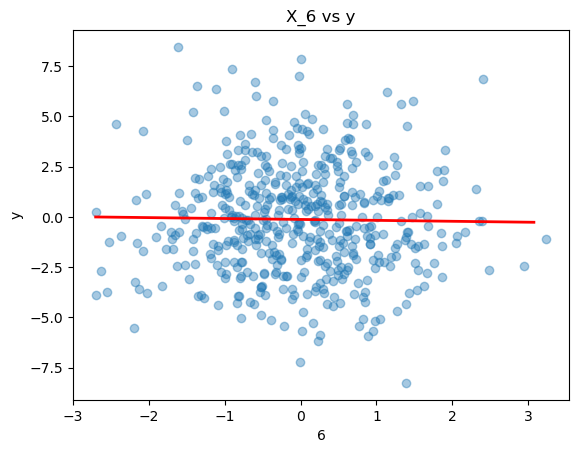

In [6]:
# reminder of gamma coeffs: gamma[:s] = [1.0, -0.8, 0.6, -0.4, 0.3]
variable = 6
plt.scatter(X[:,variable], y, alpha=0.4)
m, b = np.polyfit(X[:, variable], y, 1)
x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2)
plt.ylabel("y")
plt.xlabel(f"{variable}")
plt.title(f"X_{variable} vs y")
plt.show()


Convert data to DFs first

In [22]:
col_names = ['d'] + [f'x{i+1}' for i in range(p)]
df = pd.DataFrame(np.column_stack([d, X]), columns=col_names)
df['y'] = y

print(df.describe())

                d          x1          x2          x3          x4          x5  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean    -0.032859    0.003143    0.020149    0.005058   -0.032688   -0.006497   
std      0.969681    0.956440    1.061453    1.008065    0.980525    1.017848   
min     -2.384307   -2.703232   -2.940389   -3.241267   -2.839079   -3.019512   
25%     -0.657277   -0.607822   -0.678549   -0.681772   -0.771787   -0.660905   
50%     -0.040594    0.040920   -0.025355    0.023546    0.022736   -0.045020   
75%      0.599736    0.639625    0.749506    0.641757    0.673563    0.690822   
max      2.935658    3.076860    2.985259    3.152057    2.601683    2.755218   

               x6          x7          x8          x9         x10           y  
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000  
mean    -0.000549   -0.054563    0.004027    0.045750    0.072188   -0.125150  
std      1.041198    0.995664 

OLS

In [23]:
ols = sm.OLS(df['y'], sm.add_constant(df.drop(columns='y'))).fit()
print(ols.summary())
# reminder of gamma coeffs: gamma[:s] = [1.0, -0.8, 0.6, -0.4, 0.3] and beta0 = 2 (this is labelled x1)
print(ols.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     260.8
Date:                Mon, 18 May 2026   Prob (F-statistic):          2.38e-196
Time:                        12:15:54   Log-Likelihood:                -723.16
No. Observations:                 500   AIC:                             1470.
Df Residuals:                     488   BIC:                             1521.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0666      0.047     -1.421      0.1

Using LASSO (with theoretical lambda, Belloni (2014)) to see if only treatment and controls are recovered

In [27]:
# Setting c and alpha values for the theoretical equation lam_theory
c = 1.1
alpha = 0.05
theor_lambda = (c / np.sqrt(n)) * norm.ppf(1 - alpha / (2 * p))

# Lasso Y on X
lasso_y = Lasso(alpha=theor_lambda, max_iter=10000).fit(X, y)
S_y = set(np.where(lasso_y.coef_ !=0)[0])

# Lassy D on X
lasso_d = Lasso(alpha=theor_lambda, max_iter=10000).fit(X, d)
S_d = set(np.where(lasso_d.coef_ !=0)[0])

# Union on both
S_union = sorted(S_y | S_d)
print(f"S_union: {S_union}")

# Print reminder
print("reminder of gamma coeffs: gamma[:s] = [1.0, -0.8, 0.6, -0.4, 0.3] and d = 2")

# Post-OLS of y on d + union of selectd controls
pds = sm.add_constant(df[['d'] + [f'x{i+1}' for i in S_union]])
pds_ols = sm.OLS(df['y'], pds).fit(cov_type='HC1')
print(pds_ols.summary())



S_union: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(8)]
reminder of gamma coeffs: gamma[:s] = [1.0, -0.8, 0.6, -0.4, 0.3] and d = 2
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     499.5
Date:                Mon, 18 May 2026   Prob (F-statistic):          5.56e-219
Time:                        12:18:42   Log-Likelihood:                -724.81
No. Observations:                 500   AIC:                             1466.
Df Residuals:                     492   BIC:                             1499.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                 coef    std err          z   